In [1]:
import numpy as np
import torch
import os
import logging
import yaml
import pandas as pd
import sys
import matplotlib.pyplot as plt
from sklearn.utils import resample
torch.set_float32_matmul_precision('high')

helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier
from SimpleMAF import SimpleMAF

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
dataset_path = "/home/aegis/Titan1/NRAD/data/Scaled_Regions"
config_path = "/home/aegis/Titan1/NRAD/data/configs"
model_path = "/home/aegis/Titan1/NRAD/data/Models"

In [3]:
print("Setting up device...")
CUDA = torch.cuda.is_available()
CUDA = False
print("cuda available:", CUDA)
device = torch.device("cuda" if CUDA else "cpu")

Setting up device...
cuda available: False


In [4]:
print("Loadding MC events...")
mc_events_cr = pd.read_parquet(os.path.join(dataset_path, "MC_CR_train.parquet"))
data_events_cr = pd.read_parquet(os.path.join(dataset_path, "Data_CR_train.parquet"))

Loadding MC events...


In [5]:
context_var = ['ht', 'met_recalc_pt']
features = [col for col in mc_events_cr.columns if col not in context_var]

print("Context Variables:", context_var)
print("Feature Variables:", features)

Context Variables: ['ht', 'met_recalc_pt']
Feature Variables: ['mjj', 'pt_balance', 'dphi_j1_j2', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'min_dphi_jet_met']


In [8]:
print("Context weight training for Generate model...")
print("CR has", len(data_events_cr), "data events,", len(mc_events_cr), "MC events.")

data_cr_train_context = data_events_cr[context_var].values
mc_cr_train_context = mc_events_cr[context_var].values
data_cr_train_context = resample(data_cr_train_context, replace=False, n_samples=mc_cr_train_context.shape[0])

print("CR has", len(data_cr_train_context), "data events", len(mc_cr_train_context), "MC events")
input_x_train_CR_context = np.concatenate([data_cr_train_context, mc_cr_train_context], axis=0)

mc_cr_labels_context = np.zeros(mc_cr_train_context.shape[0]).reshape(-1, 1)
data_cr_labels_context = np.ones(data_cr_train_context.shape[0]).reshape(-1, 1)
input_y_train_CR_context = np.concatenate([data_cr_labels_context, mc_cr_labels_context], axis=0)


print("Training Data Shape (Context Weights):", input_x_train_CR_context.shape, input_y_train_CR_context.shape)

with open(f"{config_path}/context_weights_physics.yml", 'r') as stream:
    params_cw = yaml.safe_load(stream)

NN_cw = Classifier(n_inputs=len(context_var), layers=params_cw["layers"], learning_rate=params_cw["learning_rate"], device=device)
print(NN_cw.n_inputs)
print("Training context weights...")
NN_cw.train(input_x_train_CR_context, input_y_train_CR_context, save_model=True, batch_size=params_cw["batch_size"], n_epochs=params_cw["n_epochs"], model_name=f"context_weight", outdir=model_path)

print("Training Done for context weights")

Context weight training for Generate model...
CR has 39595594 data events, 4281279 MC events.
CR has 4281279 data events 4281279 MC events
Training Data Shape (Context Weights): (8562558, 2) (8562558, 1)
2
Training context weights...


 24%|==        | 12/50 [10:35<33:33, 52.99s/it]

Training Done for context weights


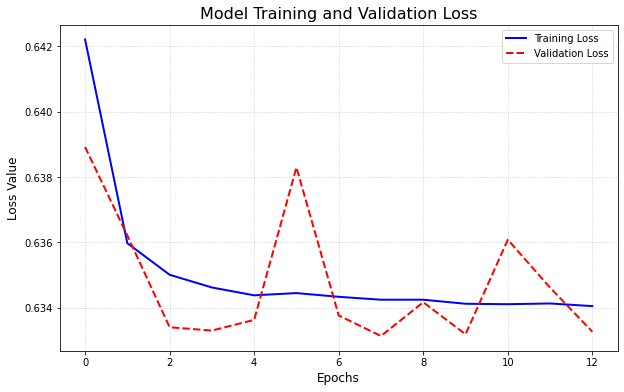

Total Epochs: 13
Final Train Loss: 0.634052
Final Val Loss: 0.633269
Minimum Validation Loss: 0.633138 at epoch 7


In [9]:
cw_loss = np.load(f"{model_path}/loss_data/context_weight_loss.npz")
# Extract the arrays using the keys you provided
epochs = cw_loss['epochs']
train_loss = cw_loss['train_loss']
val_loss = cw_loss['val_loss']

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', color='red', linewidth=2, linestyle='--')

# Formatting the chart
plt.title('Model Training and Validation Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

# Optional: Print summary statistics
print(f"Total Epochs: {len(epochs)}")
print(f"Final Train Loss: {train_loss[-1]:.6f}")
print(f"Final Val Loss: {val_loss[-1]:.6f}")
print(f"Minimum Validation Loss: {np.min(val_loss):.6f} at epoch {epochs[np.argmin(val_loss)]}")

In [10]:
print("Reweight Model ...")
print("CR has", len(data_events_cr), "data events,", len(mc_events_cr), "MC events.")

data_cr_train = data_events_cr.values
mc_cr_train = mc_events_cr.values
data_cr_train = resample(data_cr_train, replace = False, n_samples = mc_cr_train.shape[0])

print("CR has", len(data_cr_train), "data events", len(mc_cr_train), "MC events")

input_x_train_CR = np.concatenate([data_cr_train, mc_cr_train], axis=0)

mc_cr_labels = np.zeros(mc_cr_train.shape[0]).reshape(-1, 1)
data_cr_labels = np.ones(data_cr_train.shape[0]).reshape(-1, 1)
input_y_train_CR = np.concatenate([data_cr_labels, mc_cr_labels], axis=0)

print("Training Data Shape (Context Weights):", input_x_train_CR.shape, input_y_train_CR.shape)

with open(f"{config_path}/reweight_physics.yml", 'r') as stream:
    params_rw = yaml.safe_load(stream)

NN_rw = Classifier(n_inputs=(len(context_var) + len(features)), layers=params_rw["layers"], learning_rate=params_rw["learning_rate"], device=device)

print("Training context weights...")
NN_rw.train(input_x_train_CR, input_y_train_CR, save_model=True, batch_size=params_rw["batch_size"], n_epochs=params_rw["n_epochs"], model_name=f"reweight", outdir=model_path)

print("Training Done for context weights")

Reweight Model ...
CR has 39595594 data events, 4281279 MC events.
CR has 4281279 data events 4281279 MC events
Training Data Shape (Context Weights): (8562558, 10) (8562558, 1)
Training context weights...


 60%|======    | 30/50 [37:25<24:57, 74.85s/it] 


Training Done for context weights


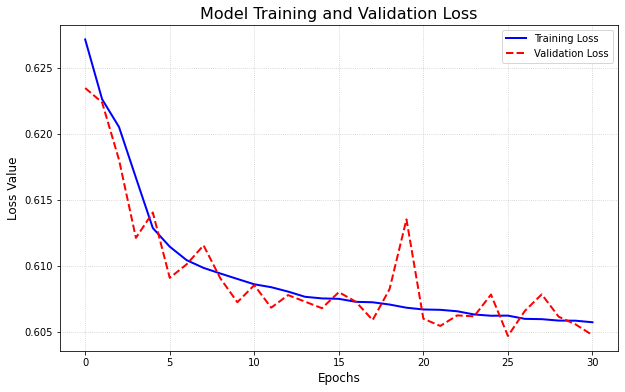

Total Epochs: 31
Final Train Loss: 0.605710
Final Val Loss: 0.604733
Minimum Validation Loss: 0.604670 at epoch 25


In [11]:
import numpy as np
import matplotlib.pyplot as plt

rw_loss = np.load(f"{model_path}/loss_data/reweight_loss.npz")
# Extract the arrays using the keys you provided
epochs = rw_loss['epochs']
train_loss = rw_loss['train_loss']
val_loss = rw_loss['val_loss']
# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', color='red', linewidth=2, linestyle='--')

# Formatting the chart
plt.title('Model Training and Validation Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

# Optional: Print summary statistics
print(f"Total Epochs: {len(epochs)}")
print(f"Final Train Loss: {train_loss[-1]:.6f}")
print(f"Final Val Loss: {val_loss[-1]:.6f}")
print(f"Minimum Validation Loss: {np.min(val_loss):.6f} at epoch {epochs[np.argmin(val_loss)]}")

In [ ]:
print("Training Generate...")
print("CR has", len(data_events_cr), "data events")

data_context_cr_train = data_events_cr[context_var].values
data_features_cr_train = data_events_cr[features].values

with open(f"{config_path}/generate_physics.yml", 'r') as stream:
    params = yaml.safe_load(stream)

MAF = SimpleMAF(num_features=len(features), num_context=len(context_var), device=device, num_layers=params["n_layers"], num_hidden_features=params["n_hidden_features"], learning_rate = params["learning_rate"])

MAF.train(data=data_features_cr_train, cond=data_context_cr_train, batch_size=params["batch_size"], n_epochs=params["n_epochs"], outdir=model_path, save_model=True, model_name=f"generate")
print("Done training!")

Training Generate...
CR has 39595594 data events


/home/aegis/Titan1/NRAD/data/model_scripts/SimpleMAF.py:242: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == 'cuda'))
 10%|=         | 2/20 [1:22:31<12:20:21, 2467.85s/it]

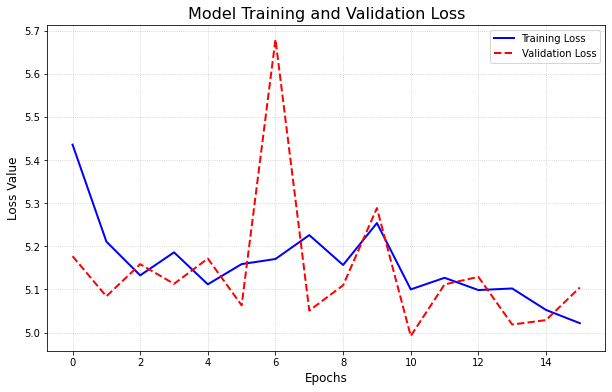

Total Epochs: 16
Final Train Loss: 5.021873
Final Val Loss: 5.104683
Minimum Validation Loss: 4.992283 at epoch 10


In [8]:
import numpy as np
import matplotlib.pyplot as plt

gen_loss = np.load(f"{model_path}/loss_data/generate_loss.npz")
# Extract the arrays using the keys you provided
epochs = gen_loss['epochs']
train_loss = gen_loss['train_loss']
val_loss = gen_loss['val_loss']
# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', color='red', linewidth=2, linestyle='--')

# Formatting the chart
plt.title('Model Training and Validation Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

# Optional: Print summary statistics
print(f"Total Epochs: {len(epochs)}")
print(f"Final Train Loss: {train_loss[-1]:.6f}")
print(f"Final Val Loss: {val_loss[-1]:.6f}")
print(f"Minimum Validation Loss: {np.min(val_loss):.6f} at epoch {epochs[np.argmin(val_loss)]}")